# DOE — design of experiments

Self-contained. Produces Excel files under `output/`.


In [1]:
# --- preamble: ensure relative paths resolve to repository_dmref root ---
import os
if os.path.basename(os.getcwd()) != 'repository_dmref':
    os.chdir('..')
print('cwd =', os.getcwd())


cwd = /data/zhq7531/IDEAL/DMREF/repository_dmref


# DOE

## L32 Taguchi

In [2]:
import itertools
import pandas as pd

# 5 base columns (A..E) at 2 levels -> 32 runs
runs = list(itertools.product([1, 2], repeat=5))
A, B, C, D, E = zip(*runs)

# F is an interaction of A and B (still orthogonal)
F = [1 if a == b else 2 for a, b in zip(A, B)]

df_coded = pd.DataFrame({
    "Run": range(1, 33),
    "A (Power)": A,
    "B (Substrate Temp)": B,
    "C (O2 flow)": C,
    "D (Pressure)": D,
    "E (Anneal cond)": E,
    "F (Anneal temp)": F,
})

# Map to your actual levels
df = pd.DataFrame({
    "Run": df_coded["Run"],
    "Power (W)": df_coded["A (Power)"].map({1: 10, "low": 10, 2: 30}),
    "Substrate Temperature (°C)": df_coded["B (Substrate Temp)"].map({1: "RT", 2: 400}),
    "Oxygen flow rate (sccm)": df_coded["C (O2 flow)"].map({1: 0.3, 2: 3.0}),
    "Background Pressure (m Torr)": df_coded["D (Pressure)"].map({1: 2, 2: 4}),
    "Annealing condition": df_coded["E (Anneal cond)"].map({1: "O2", 2: "N2"}),
    "Annealing temperature": df_coded["F (Anneal temp)"].map({1: "150 C", 2: "400 C"}),
})

# Save to Excel
df
df.to_excel("output/L32_design_inOX_BEOL.xlsx", index=False)
del A, B, C, D, E, F


In [3]:
import itertools
import pandas as pd
import numpy as np
from itertools import combinations

# -----------------------------
# 1) Full 2^6 factorial (coded 0/1)
# -----------------------------
# Factors: A=Power, B=Substrate, C=O2, D=Pressure, E=Gas, F=Anneal Temp
all_codes = list(itertools.product([0, 1], repeat=6))  # 64 combos

def map_level(val, low, high):
    return low if val == 0 else high

rows = []
for idx, (a,b,c,d,e,f) in enumerate(all_codes, start=1):
    rows.append({
        "idx": idx,                           # 1-64 full factorial index
        "Power (W)":           map_level(a, 10, 30),
        "Substrate Temp (°C)": map_level(b, "RT", 400),
        "O2 flow (sccm)":      map_level(c, 0.3, 3.0),
        "Pressure (mTorr)":    map_level(d, 2, 4),
        "Anneal gas":          map_level(e, "O2", "N2"),
        "Anneal Temp (°C)":    map_level(f, "150 C", "400 C"),
        "code": (a,b,c,d,e,f),
    })

full = pd.DataFrame(rows)

# -----------------------------
# 2) Your original 8 runs
# -----------------------------
orig_conditions = [
    (10,  "RT",  0.3, 2, "O2", "150 C"),  # Exp 1
    (10,  "RT",  0.3, 4, "N2", "400 C"),  # Exp 2
    (10,  400,   3.0, 2, "O2", "400 C"),  # Exp 3
    (10,  400,   3.0, 4, "N2", "150 C"),  # Exp 4
    (30,  "RT",  3.0, 4, "O2", "400 C"),  # Exp 5
    (30,  "RT",  3.0, 2, "N2", "150 C"),  # Exp 6
    (30,  400,   0.3, 2, "N2", "400 C"),  # Exp 7
    (30,  400,   0.3, 4, "O2", "150 C"),  # Exp 8
]

orig_idx_1based = []
for cond in orig_conditions:
    match = full[
        (full["Power (W)"]           == cond[0]) &
        (full["Substrate Temp (°C)"] == cond[1]) &
        (full["O2 flow (sccm)"]      == cond[2]) &
        (full["Pressure (mTorr)"]    == cond[3]) &
        (full["Anneal gas"]          == cond[4]) &
        (full["Anneal Temp (°C)"]    == cond[5])
    ]
    orig_idx_1based.append(int(match["idx"].iloc[0]))

print("Original 8 experiments are at full-factorial indices:", orig_idx_1based)

# -----------------------------
# 3) Precomputed 32-run subset that:
#    - is balanced (16 low / 16 high per factor)
#    - has near 8/8/8/8 pairwise counts
#    - includes all orig_idx_1based
# -----------------------------
# These indices were selected by a small greedy search over the 64 runs.
selected_indices_1based = [
    1, 8, 26, 31, 46, 43, 52, 53,   # includes all 8 original runs
    2, 63, 7, 58, 9, 56, 16, 49,
    19, 38, 29, 44, 20, 45, 30, 35,
    5, 60, 11, 54, 10, 55, 17, 48
]

design32 = full[full["idx"].isin(selected_indices_1based)].copy()
design32 = design32.sort_values("idx").reset_index(drop=True)

# give them new run numbers 1..32
design32["Run_L32"] = range(1, 33)

# mark which runs are the original L8 experiments
design32["Orig_L8"] = False
for idx in orig_idx_1based:
    design32.loc[design32["idx"] == idx, "Orig_L8"] = True

print(design32[["Run_L32", "idx",
                "Power (W)", "Substrate Temp (°C)",
                "O2 flow (sccm)", "Pressure (mTorr)",
                "Anneal gas", "Anneal Temp (°C)", "Orig_L8"]])

# Optional: save to Excel
design32.to_excel("output/L32_design_inOX_BEOL_with_L8_included.xlsx", index=False)


Original 8 experiments are at full-factorial indices: [1, 8, 26, 31, 46, 43, 52, 53]
    Run_L32  idx  Power (W) Substrate Temp (°C)  O2 flow (sccm)  \
0         1    1         10                  RT             0.3   
1         2    2         10                  RT             0.3   
2         3    5         10                  RT             0.3   
3         4    7         10                  RT             0.3   
4         5    8         10                  RT             0.3   
5         6    9         10                  RT             3.0   
6         7   10         10                  RT             3.0   
7         8   11         10                  RT             3.0   
8         9   16         10                  RT             3.0   
9        10   17         10                 400             0.3   
10       11   19         10                 400             0.3   
11       12   20         10                 400             0.3   
12       13   26         10                 

## Sobol DOE

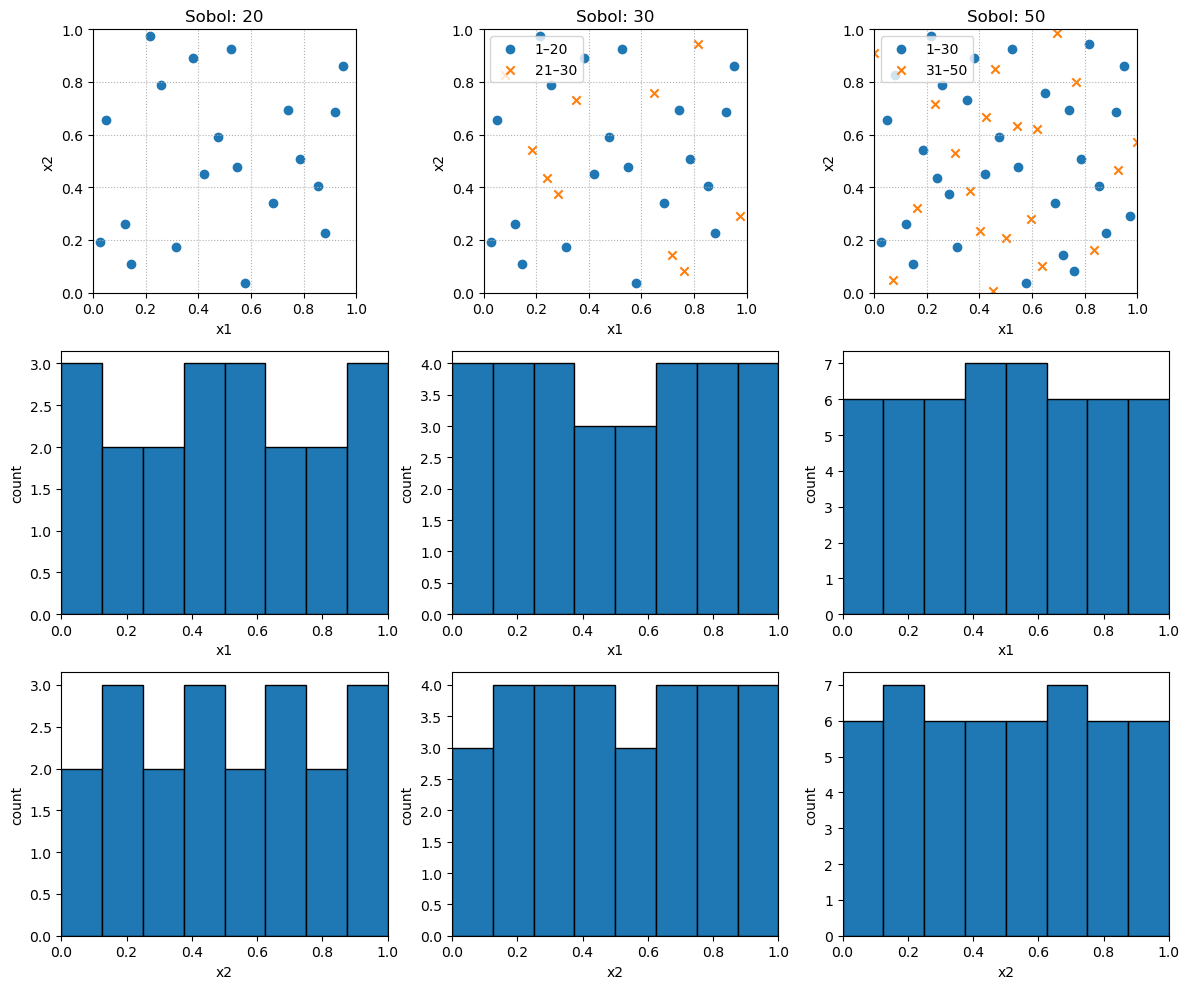

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.quasirandom import SobolEngine

# ------------------------------------------------
# 1) Build a 2D Sobol sequence and draw 50 points
# ------------------------------------------------
sobol = SobolEngine(dimension=2, scramble=True, seed=0)
samples_50 = sobol.draw(50).numpy()

# Slices
s20 = samples_50[:20]
s30 = samples_50[:30]
s50 = samples_50[:50]

s30_new = samples_50[20:30]   # 21–30
s50_new = samples_50[30:50]   # 31–50

datasets = [
    ("Sobol: 20", s20),
    ("Sobol: 30", s30),
    ("Sobol: 50", s50),
]

# ------------------------------------------------
# 2) Plot: for each n, scatter + x-hist + y-hist
# ------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for col, (title, pts) in enumerate(datasets):
    x = pts[:, 0]
    y = pts[:, 1]

    # ---------- Row 1: scatter ----------
    ax_scatter = axes[0, col]

    if col == 0:
        ax_scatter.scatter(x, y, marker="o")
    elif col == 1:
        ax_scatter.scatter(s20[:, 0], s20[:, 1], marker="o", label="1–20")
        ax_scatter.scatter(s30_new[:, 0], s30_new[:, 1], marker="x", label="21–30")
        ax_scatter.legend()
    else:
        ax_scatter.scatter(s30[:, 0], s30[:, 1], marker="o", label="1–30")
        ax_scatter.scatter(s50_new[:, 0], s50_new[:, 1], marker="x", label="31–50")
        ax_scatter.legend()

    ax_scatter.set_title(title)
    ax_scatter.set_xlabel("x1")
    ax_scatter.set_ylabel("x2")
    ax_scatter.set_xlim(0, 1)
    ax_scatter.set_ylim(0, 1)
    ax_scatter.set_aspect("equal", "box")
    ax_scatter.grid(True, linestyle=":")

    # ---------- Row 2: histogram of x1 ----------
    ax_x = axes[1, col]
    ax_x.hist(x, bins=8, range=(0, 1), edgecolor="black", linewidth=1)
    ax_x.set_xlabel("x1")
    ax_x.set_ylabel("count")
    ax_x.set_xlim(0, 1)

    # ---------- Row 3: histogram of x2 ----------
    ax_y = axes[2, col]
    ax_y.hist(y, bins=8, range=(0, 1), edgecolor="black", linewidth=1)
    ax_y.set_xlabel("x2")
    ax_y.set_ylabel("count")
    ax_y.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [5]:
import torch
import pandas as pd
from torch.quasirandom import SobolEngine

# number of Sobol points you want for the surrogate
n_samples = 30   # change this to 40, 60, etc.

# -------------------------
# Define parameter ranges
# -------------------------
# I treat RT ≈ 25 °C so the surrogate can see a continuous range
bounds = {
    "Power (W)": (10.0, 30.0),
    "Substrate Temp (°C)": (25.0, 400.0),   # RT ≈ 25 °C
    "Oxygen flow rate (sccm)": (0.3, 3.0),
    "Background Pressure (mTorr)": (2.0, 4.0),
    "Annealing temperature (°C)": (150.0, 400.0),
    # Annealing condition is categorical (O2 / N2),
    # we will generate it from a Sobol dim in [0,1]
    "Annealing condition (raw)": (0.0, 1.0),
}

param_names = list(bounds.keys())
dim = len(param_names)

# -------------------------
# Sobol in [0,1]^d
# -------------------------
engine = SobolEngine(dimension=dim, scramble=True, seed=123)
sobol_unit = engine.draw(n_samples)  # shape [n_samples, dim], values in [0,1]

# -------------------------
# Scale numeric parameters
# -------------------------
scaled = {}
for i, name in enumerate(param_names):
    low, high = bounds[name]
    # linear scaling from [0,1] to [low, high]
    scaled[name] = low + (high - low) * sobol_unit[:, i].numpy()

# Convert to DataFrame
df = pd.DataFrame(scaled)

# -------------------------
# Map annealing condition to O2 / N2
# -------------------------
df["Annealing condition"] = df["Annealing condition (raw)"].apply(
    lambda x: "O2" if x < 0.5 else "N2"
)

# Drop the raw helper column
df = df.drop(columns=["Annealing condition (raw)"])

df["Power (W)"] = df["Power (W)"].round(0).astype(int)
df["Background Pressure (mTorr)"] = df["Background Pressure (mTorr)"].round(2)#.astype(int)

df["Substrate Temp (°C)"] = df["Substrate Temp (°C)"].round(0).astype(int)
df["Annealing temperature (°C)"] = df["Annealing temperature (°C)"].round(0).astype(int)


df["Oxygen flow rate (sccm)"] = df["Oxygen flow rate (sccm)"].round(1)

# Optional: order columns to match your Taguchi table
df = df[
    [
        "Power (W)",
        "Substrate Temp (°C)",
        "Oxygen flow rate (sccm)",
        "Background Pressure (mTorr)",
        "Annealing condition",
        "Annealing temperature (°C)",
    ]
]


display(df)
print("Number of samples:", len(df))
print("Unique rows:", len(df.drop_duplicates()))
df.to_excel(
    "output/sobol_experiments.xlsx",
    index=False,
    float_format="%.2f",   # 2 decimals everywhere
)


,Power (W),Substrate Temp (°C),Oxygen flow rate (sccm),Background Pressure (mTorr),Annealing condition,Annealing temperature (°C)
0,12,243,1.4,3.98,N2,389
1,21,134,2.2,2.20,O2,152
2,30,334,0.9,3.17,O2,266
3,19,43,2.7,2.89,N2,277
4,15,365,1.9,2.65,N2,312
5,26,104,1.1,3.44,O2,229
6,23,281,2.4,2.47,O2,187
7,14,189,0.6,3.75,N2,356
8,13,320,2.6,3.37,N2,174
9,24,59,0.4,2.59,O2,382


Number of samples: 30
Unique rows: 30


## SOBOL by steps

,Power (W),Substrate Temp (°C),Oxygen flow rate (sccm),Background Pressure (mTorr),Annealing condition,Annealing temperature (°C)
0,12,400,1.4,3.98,N2,389
1,21,23,2.2,2.20,O2,152
2,30,400,0.9,3.17,O2,266
3,19,23,2.7,2.89,N2,277
4,15,400,1.9,2.65,N2,312
5,26,23,1.1,3.44,O2,229
6,23,400,2.4,2.47,O2,187
7,14,23,0.6,3.75,N2,356
8,13,400,2.6,3.37,N2,174
9,24,23,0.4,2.59,O2,382


Total samples: 20
Unique rows: 20


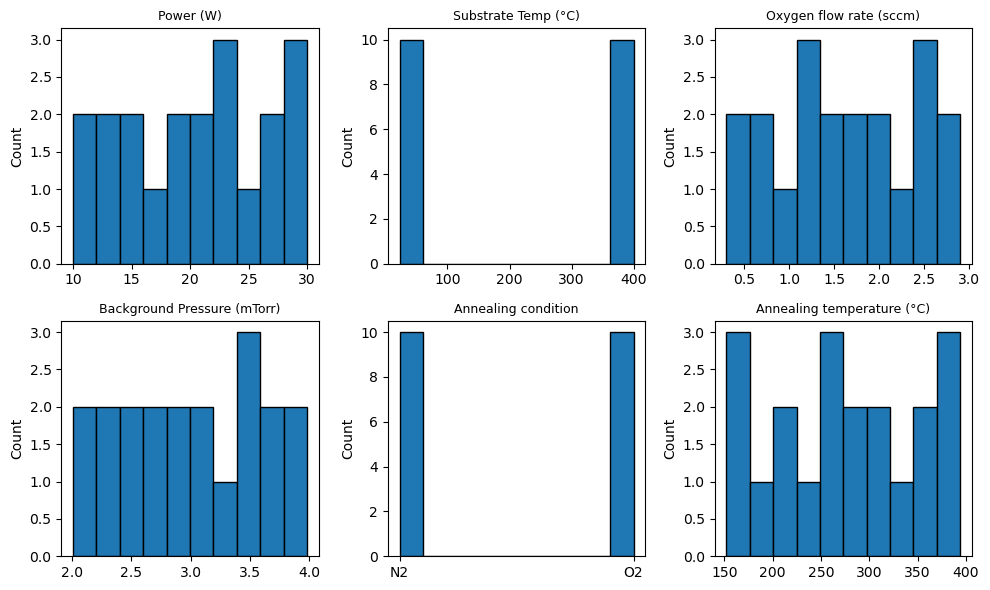

In [6]:
import torch
import pandas as pd
from torch.quasirandom import SobolEngine
import matplotlib.pyplot as plt

# -------------------------
# 1) Define parameter ranges and helpers
# -------------------------
bounds = {
    "Power (W)": (10.0, 30.0),
    "Substrate Temp (°C)": (25.0, 400.0),   # used only for info now
    "Oxygen flow rate (sccm)": (0.3, 3.0),
    "Background Pressure (mTorr)": (2.0, 4.0),
    "Annealing temperature (°C)": (150.0, 400.0),
    # Annealing condition is categorical (O2 / N2),
    # we will generate it from a Sobol dim in [0,1]
    "Annealing condition (raw)": (0.0, 1.0),
}

param_names = list(bounds.keys())
dim = len(param_names)


def sobol_to_df(sobol_unit: torch.Tensor) -> pd.DataFrame:
    """
    Map Sobol points in [0,1]^dim to your parameter ranges,
    apply rounding and categorical mapping, and return a DataFrame.
    """
    scaled = {}
    for i, name in enumerate(param_names):
        # special case: substrate temp is categorical {23, 400}
        if name == "Substrate Temp (°C)":
            raw = sobol_unit[:, i].numpy()  # in [0,1]
            scaled[name] = np.where(raw < 0.5, 23.0, 400.0)
        else:
            low, high = bounds[name]
            scaled[name] = low + (high - low) * sobol_unit[:, i].numpy()

    df = pd.DataFrame(scaled)

    # Map annealing condition to O2 / N2
    df["Annealing condition"] = df["Annealing condition (raw)"].apply(
        lambda x: "O2" if x < 0.5 else "N2"
    )
    df = df.drop(columns=["Annealing condition (raw)"])

    # Rounding rules
    df["Power (W)"] = df["Power (W)"].round(0).astype(int)
    df["Background Pressure (mTorr)"] = df["Background Pressure (mTorr)"].round(2)

    # Substrate temp is already exactly 23 or 400, rounding is harmless
    df["Substrate Temp (°C)"] = df["Substrate Temp (°C)"].round(0).astype(int)
    df["Annealing temperature (°C)"] = df["Annealing temperature (°C)"].round(0).astype(int)

    df["Oxygen flow rate (sccm)"] = df["Oxygen flow rate (sccm)"].round(1)

    # Order columns
    df = df[
        [
            "Power (W)",
            "Substrate Temp (°C)",
            "Oxygen flow rate (sccm)",
            "Background Pressure (mTorr)",
            "Annealing condition",
            "Annealing temperature (°C)",
        ]
    ]
    return df


def generate_sobol_batch(n_existing: int, n_new: int, seed: int = 123) -> pd.DataFrame:
    """
    Generate a new batch of Sobol samples, continuing after n_existing points.

    - n_existing: how many points you already used from this Sobol sequence
    - n_new: how many NEW points you want now
    - seed: keep the same seed every time so skipping works correctly
    """
    engine = SobolEngine(dimension=dim, scramble=True, seed=seed)

    # Skip the first n_existing points
    if n_existing > 0:
        _ = engine.draw(n_existing)

    # Draw only the new points
    sobol_unit_new = engine.draw(n_new)

    # Scale, round, and map to DataFrame
    df_new = sobol_to_df(sobol_unit_new)
    return df_new


# -------------------------
# 2) Example usage
# -------------------------

# First batch: 20 experiments
df_batch1 = generate_sobol_batch(n_existing=0, n_new=20, seed=123)

# Later, you decide to add 10 more experiments
# You already used 20 points, so n_existing = 20
df_batch2 = generate_sobol_batch(n_existing=20, n_new=0, seed=123)

# Combine them
df_all = pd.concat([df_batch1, df_batch2], ignore_index=True)

df_all.to_excel("output/sobol_example.xlsx",
                index=False,
                float_format="%.2f")
display(df_all)
print("Total samples:", len(df_all))
print("Unique rows:", len(df_all.drop_duplicates()))

# -------------------------
# 3) Plot distributions
# -------------------------
cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Oxygen flow rate (sccm)",
    "Background Pressure (mTorr)",
    "Annealing condition",
    "Annealing temperature (°C)",
    
]

n = len(cols)
n_rows, n_cols = 2, 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.hist(df_all[col], bins=10, edgecolor="black")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Count")

# hide any unused subplot
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Sobol with constrains v03

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from pandas.plotting import scatter_matrix

# -----------------------------------
# Configuration & Batch Settings
# -----------------------------------
n_samples = 30
seed = 42
n_repeats = 3  # Number of times each sample configuration is repeated

# To run just Batch 1, leave as [1]. 
# To run and plot both, change to [1, 2]. 
# To generate ONLY Batch 2, change to [2].
batches_to_run = [1] 

# Bounds
power_bounds = (10.0, 30.0)
oxygen_bounds = (0.3, 3.0)
pressure_bounds = (2.0, 4.0)
anneal_bounds = (150.0, 600.0)

# Sobol dimension
d = 6

def generate_batch(batch_number, n_samples, seed, d):
    """Generates a specific batch of Sobol samples."""
    m = int(np.log2(n_samples))
    if 2**m != n_samples:
        raise ValueError("n_samples must be a power of 2, e.g. 8, 16, 32, 64")

    sampler = qmc.Sobol(d=d, scramble=True, seed=seed)

    # Fast-forward the sequence if we are on a later batch
    if batch_number > 1:
        sampler.fast_forward((batch_number - 1) * n_samples)

    U = sampler.random_base2(m=m)

    # Scale independent continuous variables
    power_float = qmc.scale(U[:, [0]], [power_bounds[0]], [power_bounds[1]]).flatten()
    power = np.round(power_float).astype(int)

    oxygen = qmc.scale(U[:, [2]], [oxygen_bounds[0]], [oxygen_bounds[1]]).flatten()
    pressure = qmc.scale(U[:, [3]], [pressure_bounds[0]], [pressure_bounds[1]]).flatten()

    substrate = np.zeros(n_samples)
    anneal = np.zeros(n_samples, dtype=int) 

    u_sub = U[:, 1]  
    u_ann = U[:, 4]  
    u_cond = U[:, 5] 

    # Map Annealing Condition (50/50 split)
    anneal_cond = np.where(u_cond < 0.5, 'N', 'O')

    eps = 1e-6

    for i in range(n_samples):
        # Evaluate Substrate Temperature
        if u_sub[i] < 0.18:
            s = 25.0
        else:
            s = 400.0 + (2 * u_sub[i] - 1) * (600.0 - 400.0)
        
        substrate[i] = s

        # Evaluate Annealing Temperature
        lower_ann = max(anneal_bounds[0], s + eps)
        upper_ann = anneal_bounds[1]

        if lower_ann >= upper_ann:
            s = anneal_bounds[1] - 2.0  
            substrate[i] = s
            lower_ann = s + eps

        raw_anneal = lower_ann + u_ann[i] * (upper_ann - lower_ann)
        ann_val = int(np.round(raw_anneal))
        
        if ann_val <= s:
            ann_val = int(np.floor(s)) + 1
            
        if ann_val > int(anneal_bounds[1]):
            ann_val = int(anneal_bounds[1])
            if ann_val <= s:
                s = float(ann_val - 1)
                substrate[i] = s
                
        anneal[i] = ann_val

    # Build dataframe for this specific batch
    df = pd.DataFrame({
        "Sample": np.arange(1, n_samples + 1) + ((batch_number - 1) * n_samples),
        "Batch": batch_number,
        "Power (W)": power,
        "Substrate Temperature (C)": substrate,
        "Oxygen Flow Rate (sccm)": oxygen,
        "Background Pressure (Torr)": pressure,
        "Annealing Temperature (C)": anneal,
        "Annealing Condition": anneal_cond
    })
    
    df["Annealing Condition (0=N, 1=O)"] = np.where(df["Annealing Condition"] == 'N', 0, 1)
    df["Constraint OK"] = df["Substrate Temperature (C)"] < df["Annealing Temperature (C)"]
    
    return df

# -----------------------------------
# Execute Generation & Save Files
# -----------------------------------
all_dfs = []

for b in batches_to_run:
    df_b = generate_batch(b, n_samples, seed, d)
    
    # Rounded version for export
    df_export = df_b.copy()
    df_export = df_export.drop(columns=["Annealing Condition (0=N, 1=O)"])

    # Apply Repetitions for Excel
    df_export = df_export.loc[df_export.index.repeat(n_repeats)].reset_index(drop=True)
    df_export.insert(2, "Repetition", df_export.groupby("Sample").cumcount() + 1)

    for c in df_export.columns:
        if c not in ["Sample", "Batch", "Repetition", "Constraint OK", "Power (W)", "Annealing Temperature (C)", "Annealing Condition"]:
            df_export[c] = df_export[c].round(4)

    # Save CSV individual file
    csv_path = f"sobol_constrained_batch_{b}_repeated.xlsx"
    df_export.to_excel(csv_path, index=False)
    
    print(f"Batch {b} Generated. Constraint check passed: {df_b['Constraint OK'].all()}")
    print(f"Saved Excel to: {csv_path} (Contains {len(df_export)} total rows)\n")
    
    all_dfs.append(df_b)

# Combine all generated batches into one dataframe for plotting (WITHOUT repetitions)
df_combined = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------
# Visualizations (Combined, No Repetitions)
# -----------------------------------
plot_cols = [
    "Power (W)",
    "Substrate Temperature (C)",
    "Oxygen Flow Rate (sccm)",
    "Background Pressure (Torr)",
    "Annealing Temperature (C)",
    "Annealing Condition (0=N, 1=O)"
]

# Create dynamic strings for titles and filenames
batch_str = "_".join(map(str, batches_to_run))
title_suffix = f"Batch {batch_str}" if len(batches_to_run) == 1 else f"Batches {', '.join(map(str, batches_to_run))}"

# Color code: Blue for Batch 1, Orange for Batch 2
colors = np.where(df_combined["Batch"] == 1, 'tab:blue', 'tab:orange') if len(batches_to_run) > 1 else 'tab:blue'

axes = scatter_matrix(
    df_combined[plot_cols],
    figsize=(14, 14),
    diagonal="hist",
    alpha=0.8,
    color=colors,
    grid=False
)

# --- NEW: Rotate text in scatter matrix to 45 degrees ---
for ax in axes.flatten():
    # Rotate the variable names on the edges
    ax.xaxis.label.set_rotation(45)
    ax.xaxis.label.set_ha('right')
    ax.yaxis.label.set_rotation(45)
    ax.yaxis.label.set_ha('right')
    
    # Rotate the actual tick numbers
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=45, ha='right')

plt.suptitle(f"Sobol Pairplot - {title_suffix}", y=0.92, fontsize=16)
plt.savefig(f"sobol_pairplot_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation matrix
corr = df_combined[plot_cols].corr()
print(f"Correlation matrix ({title_suffix}):")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, interpolation="nearest", aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=45, ha="right")

ax.set_yticks(range(len(plot_cols)))
# --- NEW: Rotate y-axis text in correlation matrix to 45 degrees ---
ax.set_yticklabels(plot_cols, rotation=45, ha="right")

ax.set_title(f"Correlation matrix - {title_suffix}")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"sobol_correlation_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: n_samples must be a power of 2, e.g. 8, 16, 32, 64

## Sobol w contrained substrate 0 or 400 and above 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
import seaborn as sns 

# -----------------------------------
# Configuration & Batch Settings
# -----------------------------------
n_samples = 30
seed = 42
n_repeats = 3  # Number of times each sample configuration is repeated
prob_room_temp = 0.14  # Probability (0.0 to 1.0) of Substrate being at Room Temp (25 C)

# To run just Batch 1, leave as [1]. 
# To run and plot both, change to [1, 2]. 
# To generate ONLY Batch 2, change to [2].
batches_to_run = [1] 

# Bounds
power_bounds = (10.0, 30.0)
oxygen_bounds = (0.3, 3.0)
pressure_bounds = (2.0, 4.0)
anneal_bounds = (150.0, 600.0)

# Sobol dimension
d = 6

def generate_batch(batch_number, n_samples, seed, d):
    """Generates a specific batch of Sobol samples."""
    sampler = qmc.Sobol(d=d, scramble=True, seed=seed)

    # Fast-forward the sequence if we are on a later batch
    if batch_number > 1:
        sampler.fast_forward((batch_number - 1) * n_samples)

    # Use .random() instead of .random_base2() to allow any integer
    U = sampler.random(n=n_samples)

    # Scale independent continuous variables
    power_float = qmc.scale(U[:, [0]], [power_bounds[0]], [power_bounds[1]]).flatten()
    power = np.round(power_float).astype(int)

    oxygen = qmc.scale(U[:, [2]], [oxygen_bounds[0]], [oxygen_bounds[1]]).flatten()
    pressure = qmc.scale(U[:, [3]], [pressure_bounds[0]], [pressure_bounds[1]]).flatten()

    substrate = np.zeros(n_samples)
    anneal = np.zeros(n_samples, dtype=int) 

    u_sub = U[:, 1]  
    u_ann = U[:, 4]  
    u_cond = U[:, 5] 

    # Map Annealing Condition (50/50 split)
    anneal_cond = np.where(u_cond < 0.5, 'N', 'O')

    eps = 1e-6

    for i in range(n_samples):
        # Evaluate Substrate Temperature
        if u_sub[i] < prob_room_temp:
            s = 25.0
        else:
            # Correctly map the remaining probability range to [400, 600]
            s = 400.0 + ((u_sub[i] - prob_room_temp) / (1.0 - prob_room_temp)) * (600.0 - 400.0)
        
        substrate[i] = s

        # Evaluate Annealing Temperature
        lower_ann = max(anneal_bounds[0], s + eps)
        upper_ann = anneal_bounds[1]

        if lower_ann >= upper_ann:
            s = anneal_bounds[1] - 2.0  
            substrate[i] = s
            lower_ann = s + eps

        raw_anneal = lower_ann + u_ann[i] * (upper_ann - lower_ann)
        ann_val = int(np.round(raw_anneal))
        
        if ann_val <= s:
            ann_val = int(np.floor(s)) + 1
            
        if ann_val > int(anneal_bounds[1]):
            ann_val = int(anneal_bounds[1])
            if ann_val <= s:
                s = float(ann_val - 1)
                substrate[i] = s
                
        anneal[i] = ann_val

    # Build dataframe for this specific batch
    # --- CHANGED: Applied np.round(..., 1) directly to the arrays ---
    df = pd.DataFrame({
        "Sample": np.arange(1, n_samples + 1) + ((batch_number - 1) * n_samples),
        "Batch": batch_number,
        "Power (W)": power,
        "Substrate Temperature (C)": np.round(substrate, 1),
        "Oxygen Flow Rate (sccm)": np.round(oxygen, 1),
        "Background Pressure (Torr)": np.round(pressure, 1),
        "Annealing Temperature (C)": anneal,
        "Annealing Condition": anneal_cond
    })
    
    df["Annealing Condition (0=N, 1=O)"] = np.where(df["Annealing Condition"] == 'N', 0, 1)
    df["Constraint OK"] = df["Substrate Temperature (C)"] < df["Annealing Temperature (C)"]
    
    return df

# -----------------------------------
# Execute Generation & Save Files
# -----------------------------------
all_dfs = []

for b in batches_to_run:
    df_b = generate_batch(b, n_samples, seed, d)
    
    # Rounded version for export
    df_export = df_b.copy()
    df_export = df_export.drop(columns=["Annealing Condition (0=N, 1=O)"])

    # Apply Repetitions for Excel
    df_export = df_export.loc[df_export.index.repeat(n_repeats)].reset_index(drop=True)
    
    # Insert Repetition at index 1 (right after Sample)
    df_export.insert(1, "Repetition", df_export.groupby("Sample").cumcount() + 1)

    # Move Batch column to the far right
    cols = list(df_export.columns)
    cols.remove("Batch")
    cols.append("Batch")
    df_export = df_export[cols]

    # Save CSV individual file
    csv_path = f"output/DoE/sobol_constrained_batch_{b}_repeated.xlsx"
    df_export.to_excel(csv_path, index=False)
    
    print(f"Batch {b} Generated. Constraint check passed: {df_b['Constraint OK'].all()}")
    print(f"Saved Excel to: {csv_path} (Contains {len(df_export)} total rows)\n")
    
    all_dfs.append(df_b)

# Combine all generated batches into one dataframe for plotting (WITHOUT repetitions)
df_combined = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------
# Visualizations (Combined, No Repetitions)
# -----------------------------------

# Set a clean, professional aesthetic for the plots
sns.set_theme(style="whitegrid", palette="muted")

plot_cols = [
    "Power (W)",
    "Substrate Temperature (C)",
    "Oxygen Flow Rate (sccm)",
    "Background Pressure (Torr)",
    "Annealing Temperature (C)",
    "Annealing Condition (0=N, 1=O)"
]

# Create dynamic strings for titles and filenames
batch_str = "_".join(map(str, batches_to_run))
title_suffix = f"Batch {batch_str}" if len(batches_to_run) == 1 else f"Batches {', '.join(map(str, batches_to_run))}"

# 1. Prettier Pairplot using Seaborn
pairplot_cols = plot_cols #+ ["Batch"]

g = sns.pairplot(
    df_combined[pairplot_cols], 
    hue="Batch" if len(batches_to_run) > 1 else None,
    palette="husl" if len(batches_to_run) > 1 else None,
    diag_kind="hist",
    corner=False,
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'w'}, 
    diag_kws={'edgecolor': 'white'}
)

g.fig.suptitle(f"Sobol Pairplot - {title_suffix}", y=1.02, fontsize=16)

for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha('right')
        ax.yaxis.label.set_rotation(45)
        ax.yaxis.label.set_ha('right')
        ax.tick_params(axis='x', labelrotation=45)

plt.savefig(f"output/DoE/sobol_pairplot_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Prettier Correlation Matrix using Seaborn Heatmap
corr = df_combined[plot_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=True,      
    fmt=".2f",       
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    square=True,     
    linewidths=.5,   
    cbar_kws={"shrink": .8}, 
    ax=ax
)

ax.set_title(f"Correlation matrix - {title_suffix}", pad=20, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0) 

plt.tight_layout()
plt.savefig(f"output/DoE/sobol_correlation_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Constraint Visualization: Substrate vs Annealing Temperature
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the constraint line (y = x) and fill the diagonal infeasible region
ax.plot([0, 700], [0, 700], color='red', linestyle='--', linewidth=2, label='Limit ($T_{sub} = T_{anneal}$)')
ax.fill_between([0, 700], [0, 700], 0, color='red', alpha=0.10, label='Infeasible ($T_{sub} \geq T_{anneal}$)')

# Vertical infeasible region for the Substrate Temperature gap
ax.axvspan(25, 400, color='red', alpha=0.10, label='Infeasible ($25 < T_{sub} < 400$)')

# Scatter the actual data points (zorder=5 ensures dots sit on top of the red shading)
sns.scatterplot(
    data=df_combined,
    x="Substrate Temperature (C)",
    y="Annealing Temperature (C)",
    hue="Batch" if len(batches_to_run) > 1 else None,
    palette="husl" if len(batches_to_run) > 1 else None,
    s=100,
    alpha=0.9,
    edgecolor='w',
    zorder=5, 
    ax=ax
)

# Define limits to make the plot look clean
ax.set_xlim(-10, 650)
ax.set_ylim(100, 650)

ax.set_title(f"Constraint Space: Substrate vs. Annealing Temperature - {title_suffix}", fontsize=14, pad=15)
ax.set_xlabel("Substrate Temperature (°C)", fontsize=12, labelpad=10)
ax.set_ylabel("Annealing Temperature (°C)", fontsize=12, labelpad=10)

# Move the legend outside or to a clean spot so it doesn't cover data
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig(f"output/DoE/sobol_constraint_space_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

<>:221: SyntaxWarning: invalid escape sequence '\g'
<>:221: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3736261/3742772306.py:221: SyntaxWarning: invalid escape sequence '\g'
  ax.fill_between([0, 700], [0, 700], 0, color='red', alpha=0.10, label='Infeasible ($T_{sub} \geq T_{anneal}$)')
/tmp/ipykernel_3736261/3742772306.py:38: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(n=n_samples)
/tmp/ipykernel_3736261/3742772306.py:221: SyntaxWarning: invalid escape sequence '\g'
  ax.fill_between([0, 700], [0, 700], 0, color='red', alpha=0.10, label='Infeasible ($T_{sub} \geq T_{anneal}$)')


OSError: Cannot save file into a non-existent directory: 'output/DoE'